In [746]:
import pandas as pd

Nettoyage fr_animaux

In [747]:
path = "fr_animaux.csv"
df_animaux = pd.read_csv(path)
df_animaux

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2731,Viande de Bovins,2013,2013,Milliers de tonnes,134.00,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2731,Viande de Bovins,2013,2013,Milliers de tonnes,6.00,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2731,Viande de Bovins,2013,2013,Milliers de tonnes,140.00,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5142,Nourriture,2731,Viande de Bovins,2013,2013,Milliers de tonnes,140.00,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,645,Disponibilité alimentaire en quantité (kg/pers...,2731,Viande de Bovins,2013,2013,kg,4.59,Fc,Donnée calculée
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37161,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,5142,Nourriture,2775,Plantes Aquatiques,2013,2013,Milliers de tonnes,0.00,S,Données standardisées
37162,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,645,Disponibilité alimentaire en quantité (kg/pers...,2775,Plantes Aquatiques,2013,2013,kg,0.00,Fc,Donnée calculée
37163,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2775,Plantes Aquatiques,2013,2013,Kcal/personne/jour,0.00,Fc,Donnée calculée
37164,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2775,Plantes Aquatiques,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée


In [748]:
df_animaux.isnull().sum()
#il n'y a pas des valeures manquantes

Code Domaine              0
Domaine                   0
Code zone                 0
Zone                      0
Code Élément              0
Élément                   0
Code Produit              0
Produit                   0
Code année                0
Année                     0
Unité                     0
Valeur                    0
Symbole                   0
Description du Symbole    0
dtype: int64

In [749]:
df_animaux.info()

<class 'pandas.DataFrame'>
RangeIndex: 37166 entries, 0 to 37165
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            37166 non-null  str    
 1   Domaine                 37166 non-null  str    
 2   Code zone               37166 non-null  int64  
 3   Zone                    37166 non-null  str    
 4   Code Élément            37166 non-null  int64  
 5   Élément                 37166 non-null  str    
 6   Code Produit            37166 non-null  int64  
 7   Produit                 37166 non-null  str    
 8   Code année              37166 non-null  int64  
 9   Année                   37166 non-null  int64  
 10  Unité                   37166 non-null  str    
 11  Valeur                  37166 non-null  float64
 12  Symbole                 37166 non-null  str    
 13  Description du Symbole  37166 non-null  str    
dtypes: float64(1), int64(5), str(8)
memory usage: 4.0

In [750]:
df_animaux.columns

Index(['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément',
       'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité',
       'Valeur', 'Symbole', 'Description du Symbole'],
      dtype='str')

In [751]:
df_animaux[df_animaux.duplicated()]
#pas de doublons

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole


In [752]:
print('valeurs unique Produit',df_animaux['Produit'].unique(),"\n")
print('valeurs unique Elements',df_animaux['Élément'].unique(),"\n")
print('valeurs unique Domaine',df_animaux['Domaine'].unique(),"\n")
print('valeurs unique Code Domaine',df_animaux['Code Domaine'].unique(),"\n")
print('valeurs unique Unité',df_animaux['Unité'].unique())

valeurs unique Produit <StringArray>
[        'Viande de Bovins',   'Viande d'Ovins/Caprins',
      'Viande de Volailles',            'Viande, Autre',
         'Abats Comestible',             'Beurre, Ghee',
                    'Crème',   'Graisses Animales Crue',
                    'Oeufs',       'Lait - Excl Beurre',
       'Poissons Eau Douce',         'Viande de Suides',
       'Huiles de Poissons', 'Huiles de Foie de Poisso',
                'Perciform',      'Poissons Pelagiques',
  'Poissons Marins, Autres',                'Crustacés',
             'Cephalopodes',       'Mollusques, Autres',
 'Animaux Aquatiques Autre',       'Plantes Aquatiques',
   'Viande de Anim Aquatiq']
Length: 23, dtype: str 

valeurs unique Elements <StringArray>
[                                                   'Production',
                                       'Importations - Quantité',
                                      'Disponibilité intérieure',
                                              

In [753]:
def detect_real_unit(row):
    element = row['Élément']
    unit = row['Unité']

    if "kg" in element:
        return "kg"
    if "kg/personne/jour" in element:
        return "kg/personne/jour"
    if "Kcal/personne/jour" in element:
        return "Kcal/personne/jour"
    if "g/personne/jour" in element:
        return "g/personne/jour"
    if unit == "Milliers de tonnes":
        return "Milliers de tonnes"
    return None
df_animaux['Unite_reelle'] = df_animaux.apply(detect_real_unit, axis=1)
df_animaux['Valeur_num'] = pd.to_numeric(df_animaux['Valeur'], errors='coerce')


In [754]:
df_animaux['animaux/milliers_tonnes'] = df_animaux.apply(
    lambda row: row['Valeur_num'] if row['Unite_reelle'] == 'Milliers de tonnes' else None,
    axis=1
)


df_animaux['animaux/kcal_par_personne_jour'] = df_animaux.apply(
    lambda row: row['Valeur_num'] if row['Unite_reelle'] == 'Kcal/personne/jour' else None,
    axis=1
)

df_animaux['animaux/kg'] = df_animaux.apply(
    lambda row: row['Valeur_num'] if row['Unite_reelle'] == 'kg' else None,
    axis=1
)

df_animaux['animaux/g_par_personne_jour'] = df_animaux.apply(
    lambda row: row['Valeur_num'] if row['Unite_reelle'] == 'g/personne/jour' else None,
    axis=1
)

In [755]:
#suppressions des colonnes inutiles

df_animaux = df_animaux.drop(columns=['Code zone','Code Domaine','Code Élément','Code Produit','Unité','Valeur','Domaine','Symbole', 'Description du Symbole','Code année','Unite_reelle'])

In [756]:
df_animaux

,Zone,Élément,Produit,Année,Valeur_num,animaux/milliers_tonnes,animaux/kcal_par_personne_jour,animaux/kg,animaux/g_par_personne_jour
0,Afghanistan,Production,Viande de Bovins,2013,134.00,134.0,NaN,NaN,NaN
1,Afghanistan,Importations - Quantité,Viande de Bovins,2013,6.00,6.0,NaN,NaN,NaN
2,Afghanistan,Disponibilité intérieure,Viande de Bovins,2013,140.00,140.0,NaN,NaN,NaN
3,Afghanistan,Nourriture,Viande de Bovins,2013,140.00,140.0,NaN,NaN,NaN
4,Afghanistan,Disponibilité alimentaire en quantité (kg/pers...,Viande de Bovins,2013,4.59,NaN,NaN,4.59,NaN
...,...,...,...,...,...,...,...,...,...
37161,Zimbabwe,Nourriture,Plantes Aquatiques,2013,0.00,0.0,NaN,NaN,NaN
37162,Zimbabwe,Disponibilité alimentaire en quantité (kg/pers...,Plantes Aquatiques,2013,0.00,NaN,NaN,0.00,NaN
37163,Zimbabwe,Disponibilité alimentaire (Kcal/personne/jour),Plantes Aquatiques,2013,0.00,NaN,0.0,NaN,NaN
37164,Zimbabwe,Disponibilité de protéines en quantité (g/pers...,Plantes Aquatiques,2013,0.00,NaN,NaN,NaN,0.0


In [757]:
df_animaux.info()

<class 'pandas.DataFrame'>
RangeIndex: 37166 entries, 0 to 37165
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Zone                            37166 non-null  str    
 1   Élément                         37166 non-null  str    
 2   Produit                         37166 non-null  str    
 3   Année                           37166 non-null  int64  
 4   Valeur_num                      37166 non-null  float64
 5   animaux/milliers_tonnes         22296 non-null  float64
 6   animaux/kcal_par_personne_jour  3726 non-null   float64
 7   animaux/kg                      3726 non-null   float64
 8   animaux/g_par_personne_jour     7418 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 2.6 MB


Nettoyage fr_céréales

In [758]:
path_2 = "fr_céréales.csv"
df_cereales = pd.read_csv(path_2)
df_cereales


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2805,Riz (Eq Blanchi),2013,2013,Milliers de tonnes,342,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2513,Orge,2013,2013,Milliers de tonnes,514,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2514,Maïs,2013,2013,Milliers de tonnes,312,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2517,Millet,2013,2013,Milliers de tonnes,13,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,5511,Production,2514,Maïs,2013,2013,Milliers de tonnes,799,S,Données standardisées
887,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,5511,Production,2516,Avoine,2013,2013,Milliers de tonnes,1,S,Données standardisées
888,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,5511,Production,2517,Millet,2013,2013,Milliers de tonnes,55,S,Données standardisées
889,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,5511,Production,2518,Sorgho,2013,2013,Milliers de tonnes,69,S,Données standardisées


In [759]:
df_cereales.isnull().sum()
#pas de valeures manquantes

Code Domaine              0
Domaine                   0
Code zone                 0
Zone                      0
Code Élément              0
Élément                   0
Code Produit              0
Produit                   0
Code année                0
Année                     0
Unité                     0
Valeur                    0
Symbole                   0
Description du Symbole    0
dtype: int64

In [760]:
df_cereales.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Code Domaine            891 non-null    str  
 1   Domaine                 891 non-null    str  
 2   Code zone               891 non-null    int64
 3   Zone                    891 non-null    str  
 4   Code Élément            891 non-null    int64
 5   Élément                 891 non-null    str  
 6   Code Produit            891 non-null    int64
 7   Produit                 891 non-null    str  
 8   Code année              891 non-null    int64
 9   Année                   891 non-null    int64
 10  Unité                   891 non-null    str  
 11  Valeur                  891 non-null    int64
 12  Symbole                 891 non-null    str  
 13  Description du Symbole  891 non-null    str  
dtypes: int64(6), str(8)
memory usage: 97.6 KB


In [761]:
df_cereales[df_cereales.duplicated()]
#pas de doublon

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole


In [762]:
print('valeurs unique Produit',df_cereales['Produit'].unique(),"\n")
print('valeurs unique Elements',df_cereales['Élément'].unique(),"\n")
print('valeurs unique Domaine',df_cereales['Domaine'].unique(),"\n")
print('valeurs unique Code Domaine',df_cereales['Code Domaine'].unique(),"\n")
print('valeurs unique Unité',df_cereales['Unité'].unique())

valeurs unique Produit <StringArray>
[             'Blé', 'Riz (Eq Blanchi)',             'Orge',
             'Maïs',           'Millet',           'Seigle',
           'Avoine',           'Sorgho', 'Céréales, Autres']
Length: 9, dtype: str 

valeurs unique Elements <StringArray>
['Production']
Length: 1, dtype: str 

valeurs unique Domaine <StringArray>
['Bilans Alimentaire (Ancienne méthodologie et population)']
Length: 1, dtype: str 

valeurs unique Code Domaine <StringArray>
['FBSH']
Length: 1, dtype: str 

valeurs unique Unité <StringArray>
['Milliers de tonnes']
Length: 1, dtype: str


In [763]:
df_cereales = df_cereales.drop(columns=['Code zone','Élément','Code Domaine','Domaine','Unité','Code Produit','Symbole', 'Description du Symbole','Code année','Code Élément'])



In [764]:
#transformer milliers de tonnes en kg pour la colone valeur
df_cereales = df_cereales.rename(columns={'Valeur': 'cereale/Milliers_tonnes'})


In [765]:
df_cereales

,Zone,Produit,Année,cereale/Milliers_tonnes
0,Afghanistan,Blé,2013,5169
1,Afghanistan,Riz (Eq Blanchi),2013,342
2,Afghanistan,Orge,2013,514
3,Afghanistan,Maïs,2013,312
4,Afghanistan,Millet,2013,13
...,...,...,...,...
886,Zimbabwe,Maïs,2013,799
887,Zimbabwe,Avoine,2013,1
888,Zimbabwe,Millet,2013,55
889,Zimbabwe,Sorgho,2013,69


In [766]:
df_cereales.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Zone                     891 non-null    str  
 1   Produit                  891 non-null    str  
 2   Année                    891 non-null    int64
 3   cereale/Milliers_tonnes  891 non-null    int64
dtypes: int64(2), str(2)
memory usage: 28.0 KB


Nettoyage fr_population

In [767]:
df_cereales_zone = (
    df_cereales
    .groupby('Zone', as_index=False)['cereale/Milliers_tonnes']
    .sum()
)

In [768]:
df_cereales_zone

,Zone,cereale/Milliers_tonnes
0,Afghanistan,6350
1,Afrique du Sud,14155
2,Albanie,703
3,Algérie,4914
4,Allemagne,47757
...,...,...
162,Émirats arabes unis,55
163,Équateur,2598
164,États-Unis d'Amérique,433686
165,Éthiopie,22646


In [769]:
df_cereales_zone = df_cereales_zone.rename(
    columns={'cereale/Milliers_tonnes': '2013_total_cereales_tonne'}
)

In [770]:
df_cereales_zone

,Zone,2013_total_cereales_tonne
0,Afghanistan,6350
1,Afrique du Sud,14155
2,Albanie,703
3,Algérie,4914
4,Allemagne,47757
...,...,...
162,Émirats arabes unis,55
163,Équateur,2598
164,États-Unis d'Amérique,433686
165,Éthiopie,22646


Nettoyage Population

In [771]:
path_3 = "fr_population.csv"
df_popul = pd.read_csv(path_3)
df_popul

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,511,Population totale,2501,Population,2013,2013,1000 personnes,30552,NaN,Donnée officielle
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,511,Population totale,2501,Population,2013,2013,1000 personnes,52776,NaN,Donnée officielle
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,3,Albanie,511,Population totale,2501,Population,2013,2013,1000 personnes,3173,NaN,Donnée officielle
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,4,Algérie,511,Population totale,2501,Population,2013,2013,1000 personnes,39208,NaN,Donnée officielle
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,79,Allemagne,511,Population totale,2501,Population,2013,2013,1000 personnes,82727,NaN,Donnée officielle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,236,Venezuela (République bolivarienne du),511,Population totale,2501,Population,2013,2013,1000 personnes,30405,NaN,Donnée officielle
171,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,237,Viet Nam,511,Population totale,2501,Population,2013,2013,1000 personnes,91680,NaN,Donnée officielle
172,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,249,Yémen,511,Population totale,2501,Population,2013,2013,1000 personnes,24407,NaN,Donnée officielle
173,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,251,Zambie,511,Population totale,2501,Population,2013,2013,1000 personnes,14539,NaN,Donnée officielle


In [772]:
df_popul.isnull().sum()


Code Domaine                0
Domaine                     0
Code zone                   0
Zone                        0
Code Élément                0
Élément                     0
Code Produit                0
Produit                     0
Code année                  0
Année                       0
Unité                       0
Valeur                      0
Symbole                   174
Description du Symbole      0
dtype: int64

In [773]:
df_popul.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Code Domaine            175 non-null    str  
 1   Domaine                 175 non-null    str  
 2   Code zone               175 non-null    int64
 3   Zone                    175 non-null    str  
 4   Code Élément            175 non-null    int64
 5   Élément                 175 non-null    str  
 6   Code Produit            175 non-null    int64
 7   Produit                 175 non-null    str  
 8   Code année              175 non-null    int64
 9   Année                   175 non-null    int64
 10  Unité                   175 non-null    str  
 11  Valeur                  175 non-null    int64
 12  Symbole                 1 non-null      str  
 13  Description du Symbole  175 non-null    str  
dtypes: int64(6), str(8)
memory usage: 19.3 KB


In [774]:
df_popul[df_popul.duplicated()]
#pas de doublon

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole


In [775]:
print('valeurs unique Produit',df_popul['Produit'].unique(),"\n")
print('valeurs unique Elements',df_popul['Élément'].unique(),"\n")
print('valeurs unique Domaine',df_popul['Domaine'].unique(),"\n")
print('valeurs unique Code Domaine',df_popul['Code Domaine'].unique(),"\n")
print('valeurs unique Unité',df_popul['Unité'].unique())

valeurs unique Produit <StringArray>
['Population']
Length: 1, dtype: str 

valeurs unique Elements <StringArray>
['Population totale']
Length: 1, dtype: str 

valeurs unique Domaine <StringArray>
['Bilans Alimentaire (Ancienne méthodologie et population)']
Length: 1, dtype: str 

valeurs unique Code Domaine <StringArray>
['FBSH']
Length: 1, dtype: str 

valeurs unique Unité <StringArray>
['1000 personnes']
Length: 1, dtype: str


In [776]:
df_popul['population_millions'] = df_popul['Valeur'] / 1000

In [777]:

df_popul

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,population_millions
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,511,Population totale,2501,Population,2013,2013,1000 personnes,30552,NaN,Donnée officielle,30.552
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,202,Afrique du Sud,511,Population totale,2501,Population,2013,2013,1000 personnes,52776,NaN,Donnée officielle,52.776
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,3,Albanie,511,Population totale,2501,Population,2013,2013,1000 personnes,3173,NaN,Donnée officielle,3.173
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,4,Algérie,511,Population totale,2501,Population,2013,2013,1000 personnes,39208,NaN,Donnée officielle,39.208
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,79,Allemagne,511,Population totale,2501,Population,2013,2013,1000 personnes,82727,NaN,Donnée officielle,82.727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,236,Venezuela (République bolivarienne du),511,Population totale,2501,Population,2013,2013,1000 personnes,30405,NaN,Donnée officielle,30.405
171,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,237,Viet Nam,511,Population totale,2501,Population,2013,2013,1000 personnes,91680,NaN,Donnée officielle,91.680
172,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,249,Yémen,511,Population totale,2501,Population,2013,2013,1000 personnes,24407,NaN,Donnée officielle,24.407
173,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,251,Zambie,511,Population totale,2501,Population,2013,2013,1000 personnes,14539,NaN,Donnée officielle,14.539


In [778]:
df_popul = df_popul.drop(columns=['Code zone','Code Produit','Valeur','Code Domaine','Domaine','Symbole', 'Description du Symbole','Code année','Code Élément','Produit','Unité','Élément'])

df_popul

,Zone,Année,population_millions
0,Afghanistan,2013,30.552
1,Afrique du Sud,2013,52.776
2,Albanie,2013,3.173
3,Algérie,2013,39.208
4,Allemagne,2013,82.727
...,...,...,...
170,Venezuela (République bolivarienne du),2013,30.405
171,Viet Nam,2013,91.680
172,Yémen,2013,24.407
173,Zambie,2013,14.539


Nettoyage fr_sousalimentation

In [779]:
path_4 = "fr_sousalimentation.csv"
df_sous = pd.read_csv(path_4)
df_sous

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,7.9,F,Estimation FAO,NaN
1,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,8.8,F,Estimation FAO,NaN
2,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,9.6,F,Estimation FAO,NaN
3,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,10.2,F,Estimation FAO,NaN
4,FS,Données de la sécurité alimentaire,2,Afghanistan,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20162018,2016-2018,millions,10.6,F,Estimation FAO,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,6.6,F,Estimation FAO,NaN
1016,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,7.2,F,Estimation FAO,NaN
1017,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,7.8,F,Estimation FAO,NaN
1018,FS,Données de la sécurité alimentaire,181,Zimbabwe,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,8.2,F,Estimation FAO,NaN


In [780]:
df_sous.isnull().sum()

Code Domaine                 0
Domaine                      0
Code zone                    0
Zone                         0
Code Élément                 0
Élément                      0
Code Produit                 0
Produit                      0
Code année                   0
Année                        0
Unité                        0
Valeur                     415
Symbole                      0
Description du Symbole       0
Note                      1020
dtype: int64

In [781]:
(df_sous.isnull().mean() * 100).round(2)


Code Domaine                0.00
Domaine                     0.00
Code zone                   0.00
Zone                        0.00
Code Élément                0.00
Élément                     0.00
Code Produit                0.00
Produit                     0.00
Code année                  0.00
Année                       0.00
Unité                       0.00
Valeur                     40.69
Symbole                     0.00
Description du Symbole      0.00
Note                      100.00
dtype: float64

In [782]:
df_sous[df_sous['Valeur'].isnull()]


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
20,FS,Données de la sécurité alimentaire,79,Allemagne,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,NaN,NR,Non rapportée,NaN
21,FS,Données de la sécurité alimentaire,79,Allemagne,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,NaN,NR,Non rapportée,NaN
22,FS,Données de la sécurité alimentaire,79,Allemagne,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,NaN,NR,Non rapportée,NaN
23,FS,Données de la sécurité alimentaire,79,Allemagne,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,NaN,NR,Non rapportée,NaN
24,FS,Données de la sécurité alimentaire,79,Allemagne,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20162018,2016-2018,millions,NaN,NR,Non rapportée,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,FS,Données de la sécurité alimentaire,234,Uruguay,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20122014,2012-2014,millions,NaN,NR,Non rapportée,NaN
986,FS,Données de la sécurité alimentaire,234,Uruguay,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20132015,2013-2015,millions,NaN,NR,Non rapportée,NaN
987,FS,Données de la sécurité alimentaire,234,Uruguay,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20142016,2014-2016,millions,NaN,NR,Non rapportée,NaN
988,FS,Données de la sécurité alimentaire,234,Uruguay,6132,Valeur,210011,Nombre de personnes sous-alimentées (millions)...,20152017,2015-2017,millions,NaN,NR,Non rapportée,NaN


In [783]:
df_sous[df_sous.duplicated()]
#pas de doublon

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note


In [784]:
df_sous.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Code Domaine            1020 non-null   str    
 1   Domaine                 1020 non-null   str    
 2   Code zone               1020 non-null   int64  
 3   Zone                    1020 non-null   str    
 4   Code Élément            1020 non-null   int64  
 5   Élément                 1020 non-null   str    
 6   Code Produit            1020 non-null   int64  
 7   Produit                 1020 non-null   str    
 8   Code année              1020 non-null   int64  
 9   Année                   1020 non-null   str    
 10  Unité                   1020 non-null   str    
 11  Valeur                  605 non-null    str    
 12  Symbole                 1020 non-null   str    
 13  Description du Symbole  1020 non-null   str    
 14  Note                    0 non-null      float64
dty

In [785]:
print('valeurs unique Produit',df_sous['Produit'].unique(),"\n")
print('valeurs unique Elements',df_sous['Élément'].unique(),"\n")
print('valeurs unique Domaine',df_sous['Domaine'].unique(),"\n")
print('valeurs unique Code Domaine',df_sous['Code Domaine'].unique(),"\n")
print('valeurs unique Code Produit',df_sous['Code Produit'].unique(),"\n")
print('valeurs unique Valeur',df_sous['Valeur'].unique(),"\n")
print('valeurs unique Unité',df_sous['Unité'].unique())
	

valeurs unique Produit <StringArray>
['Nombre de personnes sous-alimentées (millions) (moyenne sur 3 ans)']
Length: 1, dtype: str 

valeurs unique Elements <StringArray>
['Valeur']
Length: 1, dtype: str 

valeurs unique Domaine <StringArray>
['Données de la sécurité alimentaire']
Length: 1, dtype: str 

valeurs unique Code Domaine <StringArray>
['FS']
Length: 1, dtype: str 

valeurs unique Code Produit [210011] 

valeurs unique Valeur <StringArray>
[ '7.9',  '8.8',  '9.6', '10.2', '10.6',  '2.6',  '2.8',  '3.2',  '3.4',
  '3.5',
 ...
  '6.8', '10.4',  '9.7',  '9.2',  '8.9',  '7.2',  '9.3',   '11',    '8',
  '8.5']
Length: 147, dtype: str 

valeurs unique Unité <StringArray>
['millions']
Length: 1, dtype: str


In [786]:
print(df_sous)

     Code Domaine                             Domaine  Code zone         Zone  \
0              FS  Données de la sécurité alimentaire          2  Afghanistan   
1              FS  Données de la sécurité alimentaire          2  Afghanistan   
2              FS  Données de la sécurité alimentaire          2  Afghanistan   
3              FS  Données de la sécurité alimentaire          2  Afghanistan   
4              FS  Données de la sécurité alimentaire          2  Afghanistan   
...           ...                                 ...        ...          ...   
1015           FS  Données de la sécurité alimentaire        181     Zimbabwe   
1016           FS  Données de la sécurité alimentaire        181     Zimbabwe   
1017           FS  Données de la sécurité alimentaire        181     Zimbabwe   
1018           FS  Données de la sécurité alimentaire        181     Zimbabwe   
1019           FS  Données de la sécurité alimentaire        181     Zimbabwe   

      Code Élément Élément 

In [787]:
df_sous = df_sous.drop(columns=['Code zone','Code Domaine','Code Produit','Domaine','Symbole', 'Description du Symbole','Année','Code Élément','Produit','Unité','Élément','Note'])
df_sous

,Zone,Code année,Valeur
0,Afghanistan,20122014,7.9
1,Afghanistan,20132015,8.8
2,Afghanistan,20142016,9.6
3,Afghanistan,20152017,10.2
4,Afghanistan,20162018,10.6
...,...,...,...
1015,Zimbabwe,20122014,6.6
1016,Zimbabwe,20132015,7.2
1017,Zimbabwe,20142016,7.8
1018,Zimbabwe,20152017,8.2


In [788]:
df_sous_20122014 = df_sous[df_sous['Code année'] == 20122014]

df_zone_valeur = df_sous_20122014[['Zone', 'Valeur']]


In [789]:
df_zone_valeur.head()

,Zone,Valeur
0,Afghanistan,7.9
5,Afrique du Sud,2.6
10,Albanie,0.2
15,Algérie,1.7
20,Allemagne,NaN


In [790]:
df_sous = df_sous.rename(columns={'Valeur': 'soualimentation/million'})


In [791]:
#df_sous['Valeur/popu/million'] = pd.to_numeric(df_sous['Valeur/popu/million'], errors='coerce').fillna(0).astype(int)
#df_sous = df_sous.rename(columns={'Valeur': 'nombre/millions'})
#df_sous = df_sous.rename(columns={'Année': 'années'})


In [792]:
df_sous

,Zone,Code année,soualimentation/million
0,Afghanistan,20122014,7.9
1,Afghanistan,20132015,8.8
2,Afghanistan,20142016,9.6
3,Afghanistan,20152017,10.2
4,Afghanistan,20162018,10.6
...,...,...,...
1015,Zimbabwe,20122014,6.6
1016,Zimbabwe,20132015,7.2
1017,Zimbabwe,20142016,7.8
1018,Zimbabwe,20152017,8.2


Nettoyage fr_vegetaux

In [793]:
path_5 = "fr_vegetaux.csv"
df_vege = pd.read_csv(path_5)
df_vege

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169.00,S,Données standardisées
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2511,Blé,2013,2013,Milliers de tonnes,1173.00,S,Données standardisées
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5072,Variation de stock,2511,Blé,2013,2013,Milliers de tonnes,-350.00,S,Données standardisées
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé,2013,2013,Milliers de tonnes,5992.00,S,Données standardisées
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5527,Semences,2511,Blé,2013,2013,Milliers de tonnes,322.00,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104866,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2680,Aliments pour enfants,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée
104867,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,684,Disponibilité de matière grasse en quantité (g...,2680,Aliments pour enfants,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée
104868,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2899,Miscellanees,2013,2013,Kcal/personne/jour,2.00,Fc,Donnée calculée
104869,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2899,Miscellanees,2013,2013,g/personne/jour,0.07,Fc,Donnée calculée


In [794]:
df_vege.isnull().sum()

Code Domaine              0
Domaine                   0
Code zone                 0
Zone                      0
Code Élément              0
Élément                   0
Code Produit              0
Produit                   0
Code année                0
Année                     0
Unité                     0
Valeur                    0
Symbole                   0
Description du Symbole    0
dtype: int64

In [795]:
df_vege.info()

<class 'pandas.DataFrame'>
RangeIndex: 104871 entries, 0 to 104870
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            104871 non-null  str    
 1   Domaine                 104871 non-null  str    
 2   Code zone               104871 non-null  int64  
 3   Zone                    104871 non-null  str    
 4   Code Élément            104871 non-null  int64  
 5   Élément                 104871 non-null  str    
 6   Code Produit            104871 non-null  int64  
 7   Produit                 104871 non-null  str    
 8   Code année              104871 non-null  int64  
 9   Année                   104871 non-null  int64  
 10  Unité                   104871 non-null  str    
 11  Valeur                  104871 non-null  float64
 12  Symbole                 104871 non-null  str    
 13  Description du Symbole  104871 non-null  str    
dtypes: float64(1), int64(5), str(8)

In [796]:
df_vege[df_vege.duplicated()]
#pas de doublon

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole


In [797]:
print('valeurs unique Produit',df_vege['Produit'].unique(),"\n")
print('valeurs unique Elements',df_vege['Élément'].unique(),"\n")
print('valeurs unique Domaine',df_vege['Domaine'].unique(),"\n")
print('valeurs unique Code Domaine',df_vege['Code Domaine'].unique(),"\n")
print('valeurs unique Unité',df_vege['Unité'].unique())

valeurs unique Produit <StringArray>
[                     'Blé',         'Riz (Eq Blanchi)',
                     'Orge',                     'Maïs',
                   'Millet',         'Céréales, Autres',
          'Pommes de Terre',             'Sucre, canne',
         'Sucre, betterave',            'Sucre Eq Brut',
       'Edulcorants Autres',                     'Miel',
      'Légumineuses Autres',                     'Noix',
     'Graines de tournesol',         'Graines de coton',
       'Coco (Incl Coprah)',                   'Sésame',
                   'Olives', 'Plantes Oleiferes, Autre',
            'Huile de Soja',         'Huile d'Arachide',
       'Huile de Tournesol',  'Huile de Colza&Moutarde',
   'Huile Graines de Coton',           'Huile de Palme',
          'Huile de Sésame',            'Huile d'Olive',
  'Huil Plantes Oleif Autr',                  'Tomates',
          'Légumes, Autres',      'Oranges, Mandarines',
          'Agrumes, Autres',                  'Bana

In [798]:
df_vege['Unite_reelle_vege'] = df_vege.apply(detect_real_unit, axis=1)
df_vege['Valeur_num_vege'] = pd.to_numeric(df_vege['Valeur'], errors='coerce')
df_vege

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Unite_reelle_vege,Valeur_num_vege
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169.00,S,Données standardisées,Milliers de tonnes,5169.00
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2511,Blé,2013,2013,Milliers de tonnes,1173.00,S,Données standardisées,Milliers de tonnes,1173.00
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5072,Variation de stock,2511,Blé,2013,2013,Milliers de tonnes,-350.00,S,Données standardisées,Milliers de tonnes,-350.00
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé,2013,2013,Milliers de tonnes,5992.00,S,Données standardisées,Milliers de tonnes,5992.00
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5527,Semences,2511,Blé,2013,2013,Milliers de tonnes,322.00,S,Données standardisées,Milliers de tonnes,322.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104866,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2680,Aliments pour enfants,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée,g/personne/jour,0.00
104867,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,684,Disponibilité de matière grasse en quantité (g...,2680,Aliments pour enfants,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée,g/personne/jour,0.00
104868,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2899,Miscellanees,2013,2013,Kcal/personne/jour,2.00,Fc,Donnée calculée,Kcal/personne/jour,2.00
104869,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2899,Miscellanees,2013,2013,g/personne/jour,0.07,Fc,Donnée calculée,g/personne/jour,0.07


In [799]:
df_vege['vege/milliers_tonnes'] = df_vege.apply(
    lambda row: row['Valeur_num_vege'] if row['Unite_reelle_vege'] == 'Milliers de tonnes' else None,
    axis=1
)


df_vege['vege/kcal_par_personne_jour'] = df_vege.apply(
    lambda row: row['Valeur_num_vege'] if row['Unite_reelle_vege'] == 'Kcal/personne/jour' else None,
    axis=1
)

df_vege['vege/kg'] = df_vege.apply(
    lambda row: row['Valeur_num_vege'] if row['Unite_reelle_vege'] == 'kg' else None,
    axis=1
)

df_vege['vege/g_par_personne_jour'] = df_vege.apply(
    lambda row: row['Valeur_num_vege'] if row['Unite_reelle_vege'] == 'g/personne/jour' else None,
    axis=1
)

df_vege

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Unite_reelle_vege,Valeur_num_vege,vege/milliers_tonnes,vege/kcal_par_personne_jour,vege/kg,vege/g_par_personne_jour
0,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5511,Production,2511,Blé,2013,2013,Milliers de tonnes,5169.00,S,Données standardisées,Milliers de tonnes,5169.00,5169.0,NaN,NaN,NaN
1,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5611,Importations - Quantité,2511,Blé,2013,2013,Milliers de tonnes,1173.00,S,Données standardisées,Milliers de tonnes,1173.00,1173.0,NaN,NaN,NaN
2,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5072,Variation de stock,2511,Blé,2013,2013,Milliers de tonnes,-350.00,S,Données standardisées,Milliers de tonnes,-350.00,-350.0,NaN,NaN,NaN
3,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé,2013,2013,Milliers de tonnes,5992.00,S,Données standardisées,Milliers de tonnes,5992.00,5992.0,NaN,NaN,NaN
4,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,2,Afghanistan,5527,Semences,2511,Blé,2013,2013,Milliers de tonnes,322.00,S,Données standardisées,Milliers de tonnes,322.00,322.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104866,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2680,Aliments pour enfants,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée,g/personne/jour,0.00,NaN,NaN,NaN,0.00
104867,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,684,Disponibilité de matière grasse en quantité (g...,2680,Aliments pour enfants,2013,2013,g/personne/jour,0.00,Fc,Donnée calculée,g/personne/jour,0.00,NaN,NaN,NaN,0.00
104868,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2899,Miscellanees,2013,2013,Kcal/personne/jour,2.00,Fc,Donnée calculée,Kcal/personne/jour,2.00,NaN,2.0,NaN,NaN
104869,FBSH,Bilans Alimentaire (Ancienne méthodologie et p...,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2899,Miscellanees,2013,2013,g/personne/jour,0.07,Fc,Donnée calculée,g/personne/jour,0.07,NaN,NaN,NaN,0.07


In [800]:
df_vege = df_vege.drop(columns=['Code zone','Code Domaine','Code Élément','Code Produit','Unité','Valeur','Domaine','Symbole', 'Description du Symbole','Code année','Unite_reelle_vege'])
df_vege

,Zone,Élément,Produit,Année,Valeur_num_vege,vege/milliers_tonnes,vege/kcal_par_personne_jour,vege/kg,vege/g_par_personne_jour
0,Afghanistan,Production,Blé,2013,5169.00,5169.0,NaN,NaN,NaN
1,Afghanistan,Importations - Quantité,Blé,2013,1173.00,1173.0,NaN,NaN,NaN
2,Afghanistan,Variation de stock,Blé,2013,-350.00,-350.0,NaN,NaN,NaN
3,Afghanistan,Disponibilité intérieure,Blé,2013,5992.00,5992.0,NaN,NaN,NaN
4,Afghanistan,Semences,Blé,2013,322.00,322.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
104866,Zimbabwe,Disponibilité de protéines en quantité (g/pers...,Aliments pour enfants,2013,0.00,NaN,NaN,NaN,0.00
104867,Zimbabwe,Disponibilité de matière grasse en quantité (g...,Aliments pour enfants,2013,0.00,NaN,NaN,NaN,0.00
104868,Zimbabwe,Disponibilité alimentaire (Kcal/personne/jour),Miscellanees,2013,2.00,NaN,2.0,NaN,NaN
104869,Zimbabwe,Disponibilité de protéines en quantité (g/pers...,Miscellanees,2013,0.07,NaN,NaN,NaN,0.07


In [801]:
df_vege.info()

<class 'pandas.DataFrame'>
RangeIndex: 104871 entries, 0 to 104870
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Zone                         104871 non-null  str    
 1   Élément                      104871 non-null  str    
 2   Produit                      104871 non-null  str    
 3   Année                        104871 non-null  int64  
 4   Valeur_num_vege              104871 non-null  float64
 5   vege/milliers_tonnes         67783 non-null   float64
 6   vege/kcal_par_personne_jour  10607 non-null   float64
 7   vege/kg                      10381 non-null   float64
 8   vege/g_par_personne_jour     16100 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 7.2 MB


merge des dataset

In [802]:
#merge animaux et vegetaux
etape_1=df_cereales_zone.merge(
df_popul, on=['Zone'],how='left') # inner car le nombre de pays est identique 


#merge etape_2 avec population
etape_2=etape_1.merge(df_zone_valeur, on=('Zone'),how='left')
etape_2 = etape_2.rename(columns={'Valeur': 'soualimentation/million'})

In [803]:
etape_1

,Zone,2013_total_cereales_tonne,Année,population_millions
0,Afghanistan,6350,2013,30.552
1,Afrique du Sud,14155,2013,52.776
2,Albanie,703,2013,3.173
3,Algérie,4914,2013,39.208
4,Allemagne,47757,2013,82.727
...,...,...,...,...
162,Émirats arabes unis,55,2013,9.346
163,Équateur,2598,2013,15.738
164,États-Unis d'Amérique,433686,2013,320.051
165,Éthiopie,22646,2013,94.101


In [804]:
etape_2

,Zone,2013_total_cereales_tonne,Année,population_millions,soualimentation/million
0,Afghanistan,6350,2013,30.552,7.9
1,Afrique du Sud,14155,2013,52.776,2.6
2,Albanie,703,2013,3.173,0.2
3,Algérie,4914,2013,39.208,1.7
4,Allemagne,47757,2013,82.727,NaN
...,...,...,...,...,...
162,Émirats arabes unis,55,2013,9.346,0.4
163,Équateur,2598,2013,15.738,1.3
164,États-Unis d'Amérique,433686,2013,320.051,NaN
165,Éthiopie,22646,2013,94.101,25.3


In [805]:
import sweetviz as sv

#report = sv.analyze(df_zone_valeur)

In [806]:
#report_sous = sv.analyze(etape_2)

In [807]:
#report.show_html()

In [808]:
#report_sous.show_html()

In [809]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [810]:
etape_2['soualimentation/million'] = etape_2['soualimentation/million'].replace('<0.1', 0.1)
etape_2['soualimentation/million'] = pd.to_numeric(etape_2['soualimentation/million'], errors='coerce')
df_num = etape_2[['2013_total_cereales_tonne', 'population_millions', 'soualimentation/million']]
corr = df_num.corr()


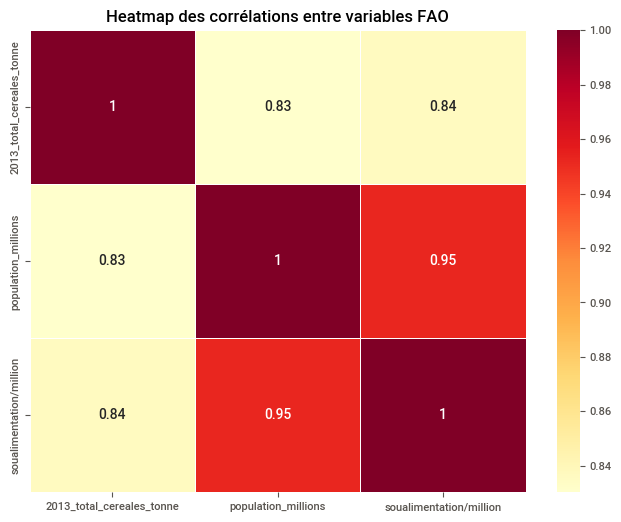

In [814]:
df_multi = etape_2.set_index('Zone')[['2013_total_cereales_tonne', 'population_millions', 'soualimentation/million']]

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='YlOrRd', linewidths=.5)
plt.title("Heatmap des corrélations entre variables FAO")
plt.show()

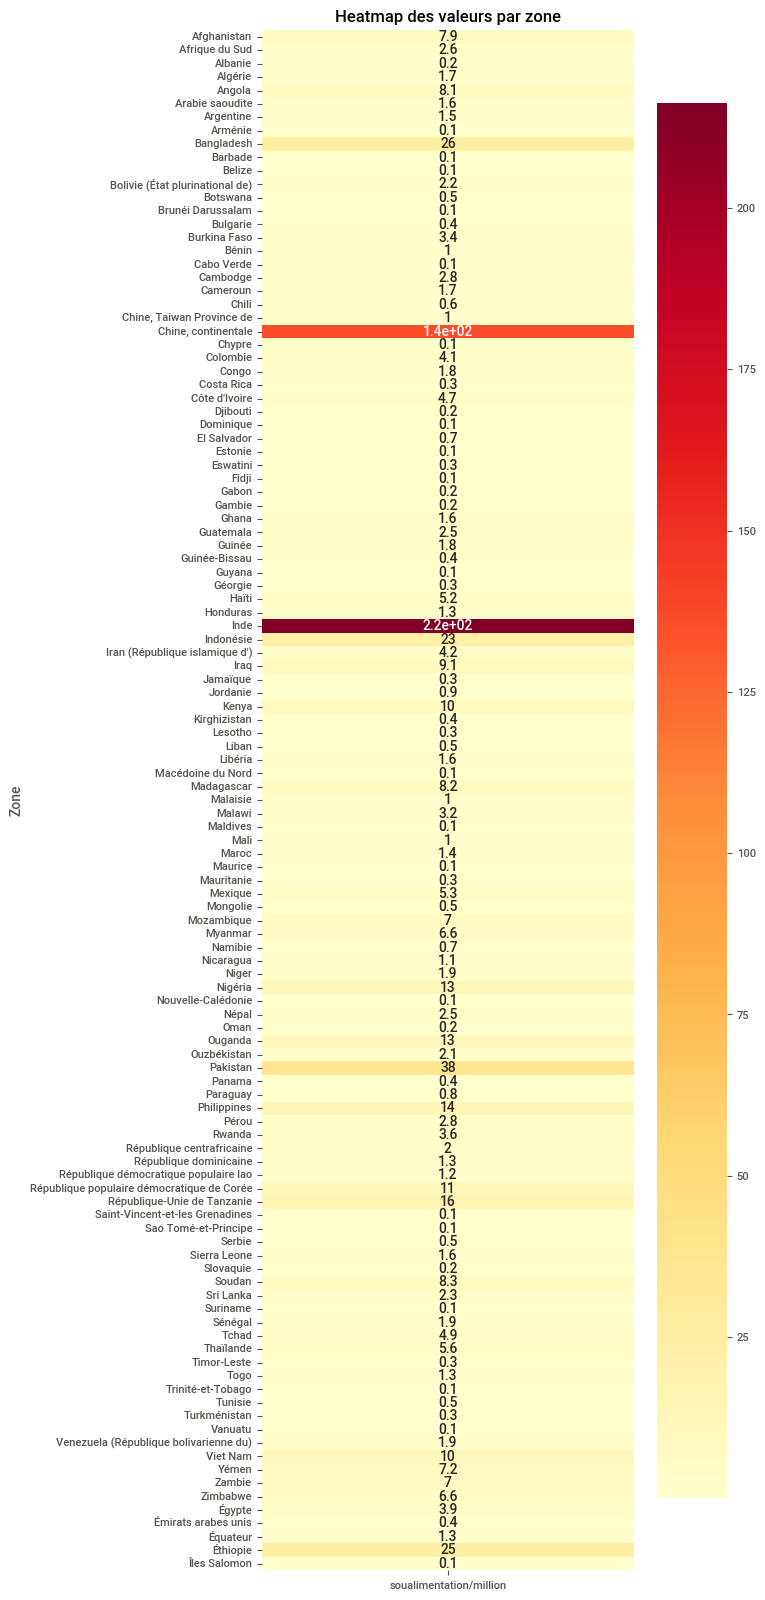

In [813]:
df_pivot = etape_2.pivot_table(index='Zone', values='soualimentation/million')

plt.figure(figsize=(6,20))
sns.heatmap(df_pivot, annot=True, cmap='YlOrRd')
plt.title("Heatmap des valeurs par zone")
plt.show()